<div class="alert alert-block alert-info"> <b> Método de aceleración de Anderson </b> </div>

**Introducción.** Consideramos un problema general de punto fijo y la iteración de punto fijo asociada de la siguiente manera.

**Problema PF.** Dado $g: \mathbb{R}^n \to \mathbb{R}^n$, resuelva $x = g(x)$.

**ALGORITMO IPF. ITERACIÓN DE PUNTO FIJO.**
> Dado $x_0$.
> Para $k = 0, 1, \ldots$
> Establecer $x_{k+1} = g(x_k)$.

Los problemas de punto fijo abundan en la ciencia computacional y la ingeniería, aunque no siempre se consideren o traten como tales. Existe una dualidad natural entre el **Problema PF** y un problema de ecuaciones no lineales: resolver $$f(x) \equiv g(x) - x = 0$$

La principal preocupación asociada generalmente con la iteración de punto fijo es que las iteraciones pueden no converger o, si lo hacen, exhibir solo una convergencia lineal, lo que puede ser inaceptablemente lento. Los métodos de aceleración pueden aliviar potencialmente la convergencia lenta y, en algunos casos, también la divergencia. Nuestro interés aquí radica en un método de aceleración particular que se origina en el trabajo de Anderson, al que nos referimos como **aceleración de Anderson** y formulamos de la siguiente manera.

**ALGORITMO AA. ACELERACIÓN DE ANDERSON.**
> Dados $x_0$ y $m \ge 1$.
>
> Establecer $x_1 = g(x_0)$.
>
> Para $k = 1, 2, \ldots$
> 
> $\quad$ Establecer $m_k = \min\{m, k\}$.
> 
> $\quad$ Establecer $f_i = g(x_{k-m_k+i}) - x_{k-m_k+i}$.
> 
> $\quad$ Establecer $F_k = (f_{k-m_k}, \ldots, f_k)^T$.
> 
> $\quad$ Determinar $\alpha^{(k)} = (\alpha_0^{(k)}, \ldots, \alpha_{m_k}^{(k)})^T$ que resuelve
>
> (1.1) $\quad \min_{\alpha=(\alpha_0,\ldots,\alpha_{m_k})^T} \|\mathbf{F}_k\alpha\|_2 \quad \text{s.a.} \quad \sum_{i=0}^{m_k} \alpha_i = 1.$
>
> $\quad$ Establecer $x_{k+1} = \sum_{i=0}^{m_k} \alpha_i^{(k)} g(x_{k-m_k+i})$.

En la práctica, cada $m_k$ puede modificarse adicionalmente, por ejemplo, para mantener un condicionamiento aceptable de $F_k$. La formulación original en permite un paso más general,

(1.2) $$\quad x_{k+1} = (1-\beta_k) \sum_{i=0}^{m_k} \alpha_i^{(k)} x_{k-m_k+i} + \beta_k \sum_{i=0}^{m_k} \alpha_i^{(k)} g(x_{k-m_k+i})$$

donde $\beta_k > 0$ es un parámetro de relajación. Es apropiado aquí considerar solo $\beta_k = 1$, lo que da el paso en el Algoritmo $\text{AA}^2$. También el problema de mínimos cuadrados (1.1) se formula como un problema equivalente de mínimos cuadrados sin restricciones:

$$\quad \min_{(\theta_1,\ldots,\theta_{m_k})} \left\| f_k + \sum_{i=1}^{m_k} \theta_i (f_{k-i} - f_k) \right\|_2$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Problema de punto fijo ---

# Queremos resolver x^3 - x - 1 = 0.
# Reformulamos como problema de punto fijo: x = g(x)
# Opción: x = g(x) = (x + 1)**(1/3)

def g(x):
    return (x + 1)**(1/3)

def f_error(x, g_x):
    return g_x - x

def fixed_point_iteration(g, x0, max_iter=100, tol=1e-8):
    x = x0
    errors = []
    
    for k in range(max_iter):
        x_new = g(x)
        error = np.linalg.norm(x_new - x)
        errors.append(error)
        
        if error < tol:
            break
        x = x_new
        
    return x, errors

# --- Aceleración de Anderson ---

def anderson_acceleration(g, x0, m=5, max_iter=100, tol=1e-8):
    n = 1 # Dimensión del problema (para este ejemplo es 1)
    x = np.array([x0])
    x_hist = [x]
    g_hist = [g(x)]
    errors = []
    
    for k in range(1, max_iter):
        # Longitud de la ventana
        mk = min(m, k)
        
        # 1. Calcular el vector F y la matriz G
        # Los residuos son f_i = g(x_i) - x_i
        
        # Residuos (f_k-m, ..., f_k-1)
        F_window = []
        for i in range(mk):
            # f_{k-mk+i} = g(x_{k-mk+i}) - x_{k-mk+i}
            f_i = g_hist[k-mk+i] - x_hist[k-mk+i]
            F_window.append(f_i.flatten())
        
        F_window = np.array(F_window).T # Matriz de residuos F_k (tamaño n x mk)

        # Matriz G para el sistema de mínimos cuadrados
        # G = [ f_{k-m} - f_k | ... | f_{k-1} - f_k ] (tamaño n x (mk-1))
        
        if mk == 1:
            # Caso especial: solo hay un punto. Usamos el paso simple de punto fijo.
            x_new = g_hist[-1] 
        else:
            # Residuo actual f_k-1 (usamos el último de la ventana)
            f_k_1 = F_window[:, -1]
            
            # Matriz delta F: Diferencias de residuos [ f_{k-m}-f_{k-1} | ... | f_{k-2}-f_{k-1} ]
            # Nota: Algunos autores usan diferentes índices, pero el concepto es minimizar el residuo.
            
            # Construimos la matriz A para el sistema de mínimos cuadrados sin restricciones:
            # min || f_{k-1} + sum_{i=1}^{m-1} theta_i (f_{k-m+i} - f_{k-1}) ||_2
            
            A = F_window[:, :-1] - f_k_1[:, np.newaxis] # f_i - f_{k-1} para i=k-mk hasta k-2
            b = -f_k_1 # Vector b = -f_{k-1}

            # 2. Resolver el problema de mínimos cuadrados para theta (coeficientes)
            # A theta = b
            theta, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
            
            # 3. Calcular los coeficientes alpha a partir de theta (para la combinación convexa)
            # alpha_i = theta_i para i=1..m-1. alpha_m = 1 - sum(theta)
            # Aquí: alpha_i = theta_i para i=0..m-2. alpha_{m-1} = 1 - sum(theta)
            
            # Coeficientes alpha para x_k-mk, ..., x_k-1
            alpha = np.zeros(mk)
            alpha[:-1] = theta
            alpha[-1] = 1.0 - np.sum(theta)
            
            # 4. Calcular la nueva aproximación x_{k+1}
            # x_{k+1} = sum_{i=0}^{m-1} alpha_i * g(x_{k-mk+i})
            
            X_G_window = np.array([g_hist[k-mk+i] for i in range(mk)]).T # Matriz n x mk de g(x)
            
            # La nueva aproximación es una combinación lineal de g(x)
            x_new = X_G_window @ alpha

        # 5. Actualizar historiales y verificar convergencia
        x_new = x_new.flatten()
        g_x_new = g(x_new)
        
        error = np.linalg.norm(g_x_new - x_new)
        errors.append(error)
        
        if error < tol:
            break
        
        x_hist.append(x_new)
        g_hist.append(g_x_new)
        x = x_new
        
    return x, errors

# --- Ejecución y Comparación ---

x0 = 1.5 # Punto de inicio (cerca de la raíz real ~1.32)
max_iter = 100

# 4.1. Ejecutar IPF
x_fpi, errors_fpi = fixed_point_iteration(g, x0, max_iter=max_iter)

# 4.2. Ejecutar AA
m_aa = 5 # Ventana de aceleración de Anderson
x_aa, errors_aa = anderson_acceleration(g, x0, m=m_aa, max_iter=max_iter)

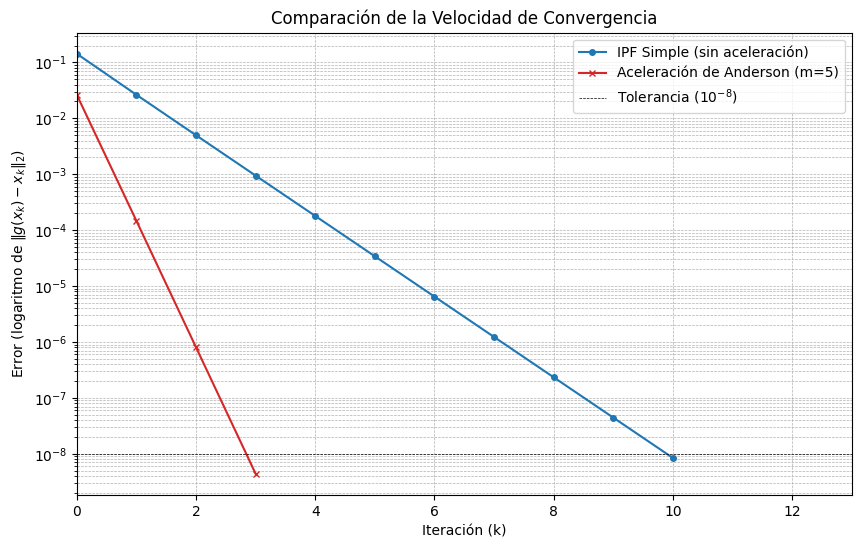

Raíz aproximada (IPF): 1.3247179676
Iteraciones (IPF): 11
------------------------------
Raíz aproximada (AA): 1.3247189500
Iteraciones (AA, m=5): 4


In [3]:
plt.figure(figsize=(10, 6))

# Tasa de convergencia (logaritmo del error)
plt.semilogy(errors_fpi, 'o-', label='IPF Simple (sin aceleración)', markersize=4, color='tab:blue')
plt.semilogy(errors_aa, 'x-', label=f'Aceleración de Anderson (m={m_aa})', markersize=4, color='tab:red')

# Añadir línea de tolerancia
plt.axhline(y=1e-8, color='k', linestyle='--', linewidth=0.5, label='Tolerancia ($10^{-8}$)')

plt.title('Comparación de la Velocidad de Convergencia')
plt.xlabel('Iteración (k)')
plt.ylabel('Error (logaritmo de $\|g(x_k) - x_k\|_2$)')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.xlim(0, max(len(errors_fpi), len(errors_aa)) + 2)
plt.show()

# Resumen
print(f"Raíz aproximada (IPF): {x_fpi:.10f}")
print(f"Iteraciones (IPF): {len(errors_fpi)}")
print("-" * 30)
print(f"Raíz aproximada (AA): {x_aa.item():.10f}")
print(f"Iteraciones (AA, m={m_aa}): {len(errors_aa)}")

**Referencias**

Hablé con el profe Barnafi y me recomendó el paper:

"Walker, H. F., & Ni, P. (2011). Anderson acceleration for fixed-point iterations. SIAM Journal on Numerical Analysis, 49(4), 1715–1735"